# Persistent Homology and Topological Signatures

Persistent homology tracks birth/death of topological features across scales.
For connected components ($H_0$), bar lengths are related to MST edge lengths.
We illustrate $H_0$ persistence on point clouds with two clusters.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/persistent-homology-topology/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/persistent-homology-topology") if Path("python/persistent-homology-topology").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Persistent Homology and Topological Signatures**, with equations and plots designed to expose both the model and the numerical behavior.


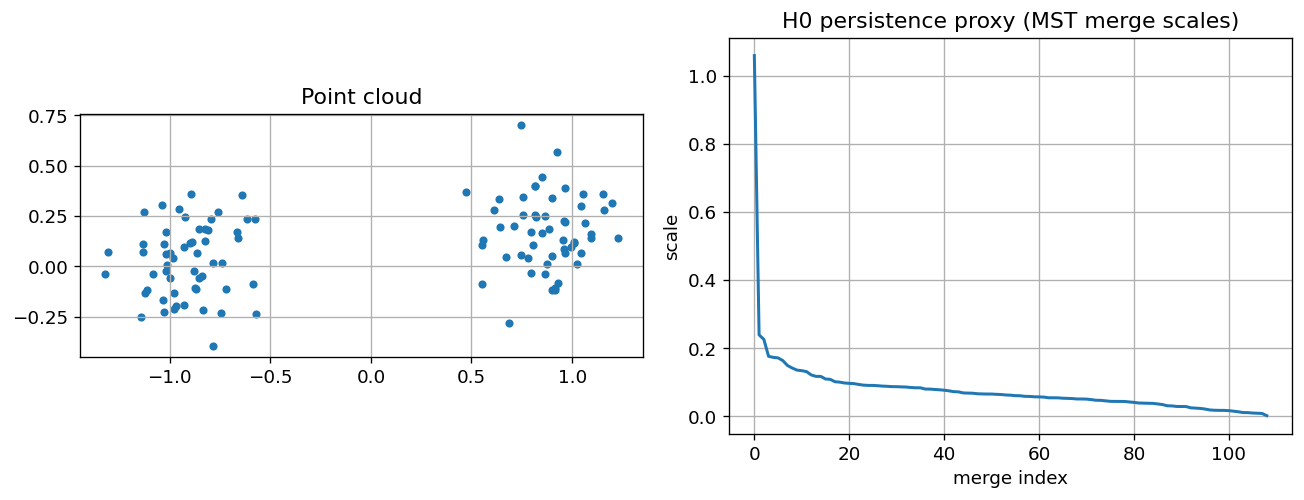

In [2]:
n1, n2 = 55, 55
X1 = 0.18*rng.normal(size=(n1, 2)) + np.array([-0.9, 0.0])
X2 = 0.18*rng.normal(size=(n2, 2)) + np.array([0.9, 0.15])
X = np.vstack([X1, X2])
N = len(X)

D = np.sqrt(np.sum((X[:, None, :] - X[None, :, :])**2, axis=2))
edges = []
for i in range(N):
    for j in range(i + 1, N):
        edges.append((D[i, j], i, j))
edges.sort()

parent = np.arange(N)
size = np.ones(N, dtype=int)

def find(a):
    while parent[a] != a:
        parent[a] = parent[parent[a]]
        a = parent[a]
    return a

bars = []
for w, i, j in edges:
    ri, rj = find(i), find(j)
    if ri != rj:
        if size[ri] < size[rj]:
            ri, rj = rj, ri
        parent[rj] = ri
        size[ri] += size[rj]
        bars.append(w)
    if len(bars) == N - 1:
        break

bars = np.array(bars)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].scatter(X[:, 0], X[:, 1], s=15)
axes[0].set_title("Point cloud")
axes[0].set_aspect("equal")

axes[1].plot(np.sort(bars)[::-1], lw=1.8)
axes[1].set_title("H0 persistence proxy (MST merge scales)")
axes[1].set_xlabel("merge index")
axes[1].set_ylabel("scale")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- H. Edelsbrunner, J. Harer, *Computational Topology: An Introduction*, AMS, 2010.
- R. Ghrist, "Barcodes: The Persistent Topology of Data", Bull. AMS, 2008.
- G. Carlsson, "Topology and Data", Bull. AMS, 2009.
